In [ ]:
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

%matplotlib inline

In [2]:
class Model(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.l1 = nn.Linear(2, 42, dtype=torch.float64)
        self.l2 = nn.Linear(42, 1, dtype=torch.float64)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x1 = self.relu(self.l1(x))
        x2 = self.sigmoid(self.l2(x1))
        return x2

In [3]:
a = torch.rand(size=(512, 2)) * 4.5
label_a = torch.zeros(512)
b = torch.rand((2048, 2)) * 5 + 5
label_b = torch.ones(2048)

indices = torch.randperm(a.size(0) + b.size(0))
t_point = torch.cat((a, b), dim=0)[indices].to(torch.float64)
label = torch.cat((label_a, label_b), dim=0)[indices].to(torch.float64)

lf = nn.BCELoss()
model = Model()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

dataset = TensorDataset(t_point, label)
dl = DataLoader(dataset, batch_size=12, shuffle=True)

In [ ]:
epochs = 40
i = 0
for _ in range(epochs):
    total_loss = []
    model.train()
    for X, y in dl:
        outputs = model(X)
        loss = lf(outputs.squeeze(1), y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss.append(loss)
        if i < 5:
            print(f"X: {X}")
            print(f"y: {y}")
            i += 1



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

{0: tensor([2.2337e-06], dtype=torch.float64), 1: tensor([1.0000], dtype=torch.float64), 2: tensor([1.0000], dtype=torch.float64), 3: tensor([1.0000], dtype=torch.float64), 4: tensor([1.0000], dtype=torch.float64), 5: tensor([1.0000], dtype=torch.float64), 6: tensor([1.0000], dtype=torch.float64), 7: tensor([1.0000], dtype=torch.float64), 8: tensor([7.3417e-06], dtype=torch.float64), 9: tensor([1.0000], dtype=torch.float64), 10: tensor([0.9998], dtype=torch.float64), 11: tensor([3.0238e-07], dtype=torch.float64), 12: tensor([1.0000], dtype=torch.float64), 13: tensor([1.0000], dtype=torch.float64), 14: tensor([1.0000], dtype=torch.float64), 15: tensor([1.0000], dtype=torch.float64), 16: tensor([1.0000], dtype=torch.float64), 17: tensor([1.0000], dtype=torch.float64), 18: tensor([1.0000], dtype=torch.float64), 19: tensor([1.0000], dtype=torch.float64), 20: tensor([7.9440e-05], dtype=torch.float64), 21: tensor([1.0000], dtype=torch.float64), 22: tensor([1.0000], dtype=torch.float64), 23: 

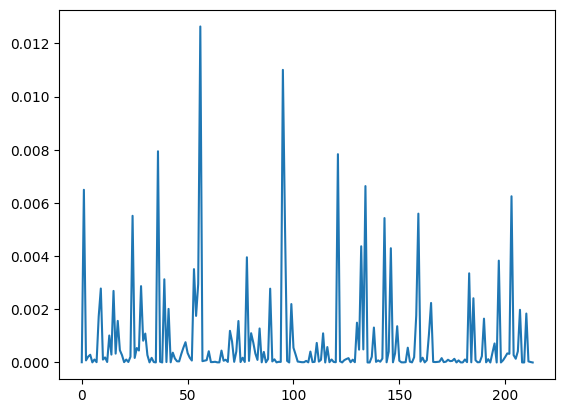

In [5]:
model.eval()
with torch.no_grad():
    plt.plot(total_loss)
    print(dict(enumerate(model(t_point[24:73]))))
    print(dict(enumerate(label[24:73])))